# Project 3: Network Intrusion Detection using DBSCAN
## Project Objective

Build an anomaly detection system that identifies suspicious network traffic using the DBSCAN clustering algorithm. Normal traffic forms dense clusters, while unusual or malicious traffic is detected as noise points.

## Problem Statement

Cyber attacks such as DoS, Probe, U2R, and R2L can compromise network security. Traditional supervised models require labeled attack data, but new attack types may not be labeled.

This project uses DBSCAN, an unsupervised learning algorithm, to detect anomalous network connections without predefined attack labels.

## Business Problem

An organization wants to automatically identify suspicious network activities that may indicate cyber attacks.

## Goal:

Detect abnormal network behavior
Identify potential attacks
Reduce manual monitoring effort
Improve cybersecurity

## Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

# Step 2 : Load Dataset

In [3]:
column_names = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "attack",
    "difficulty"
]


In [4]:
df = pd.read_csv('KDDTrain+.txt', names = column_names)

In [5]:
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


# Step 3 : Basic EDA

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [7]:
df.dtypes

duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [8]:
df.isna().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


# Step 4: Understand the Features

In [11]:
#4.1 Identify Categorical Features
cat_features = df.select_dtypes(include=['object']).columns
cat_features

Index(['protocol_type', 'service', 'flag', 'attack'], dtype='str')

In [12]:
for i in cat_features:
    print(f"\n{i}")
    print(f"Number of unique values: {df[i].nunique()}")
    print(df[i].unique())
    


protocol_type
Number of unique values: 3
<StringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str

service
Number of unique values: 70
<StringArray>
[   'ftp_data',       'other',     'private',        'http',  'remote_job',
        'name',  'netbios_ns',       'eco_i',         'mtp',      'telnet',
      'finger',    'domain_u',      'supdup',   'uucp_path',      'Z39_50',
        'smtp',    'csnet_ns',        'uucp', 'netbios_dgm',       'urp_i',
        'auth',      'domain',         'ftp',         'bgp',        'ldap',
       'ecr_i',      'gopher',       'vmnet',      'systat',    'http_443',
         'efs',       'whois',       'imap4',    'iso_tsap',        'echo',
      'klogin',        'link',      'sunrpc',       'login',      'kshell',
     'sql_net',        'time',   'hostnames',        'exec',       'ntp_u',
     'discard',        'nntp',     'courier',         'ctf',         'ssh',
     'daytime',       'shell',     'netstat',       'pop_3',        'nnsp',
         'IR

In [13]:
df["protocol_type"].unique()

<StringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str

In [14]:
df["service"].unique()

<StringArray>
[   'ftp_data',       'other',     'private',        'http',  'remote_job',
        'name',  'netbios_ns',       'eco_i',         'mtp',      'telnet',
      'finger',    'domain_u',      'supdup',   'uucp_path',      'Z39_50',
        'smtp',    'csnet_ns',        'uucp', 'netbios_dgm',       'urp_i',
        'auth',      'domain',         'ftp',         'bgp',        'ldap',
       'ecr_i',      'gopher',       'vmnet',      'systat',    'http_443',
         'efs',       'whois',       'imap4',    'iso_tsap',        'echo',
      'klogin',        'link',      'sunrpc',       'login',      'kshell',
     'sql_net',        'time',   'hostnames',        'exec',       'ntp_u',
     'discard',        'nntp',     'courier',         'ctf',         'ssh',
     'daytime',       'shell',     'netstat',       'pop_3',        'nnsp',
         'IRC',       'pop_2',     'printer',       'tim_i',     'pm_dump',
       'red_i', 'netbios_ssn',         'rje',         'X11',       'urh_i'

In [15]:
df['attack'].unique()

<StringArray>
[         'normal',         'neptune',     'warezclient',         'ipsweep',
       'portsweep',        'teardrop',            'nmap',           'satan',
           'smurf',             'pod',            'back',    'guess_passwd',
       'ftp_write',        'multihop',         'rootkit', 'buffer_overflow',
            'imap',     'warezmaster',             'phf',            'land',
      'loadmodule',             'spy',            'perl']
Length: 23, dtype: str

In [16]:
df['flag'].unique()

<StringArray>
['SF', 'S0', 'REJ', 'RSTR', 'SH', 'RSTO', 'S1', 'RSTOS0', 'S3', 'S2', 'OTH']
Length: 11, dtype: str

In [17]:
for col in ["protocol_type", "service", "flag", "attack"]:
    print(f"{col}: {df[col].nunique()} unique values")

protocol_type: 3 unique values
service: 70 unique values
flag: 11 unique values
attack: 23 unique values


In [18]:
df["attack"].value_counts()

attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [19]:
df['protocol_type'].value_counts()

protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

In [20]:
df['flag'].value_counts()

flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64

In [21]:
df['service'].value_counts()

service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6860
             ...  
tftp_u           3
http_8001        2
aol              2
harvest          2
http_2784        1
Name: count, Length: 70, dtype: int64

In [22]:
cat_features = ["protocol_type", "service", "flag"]

for col in cat_features:
    freq_map = df[col].value_counts(normalize=True)
    df[col] = df[col].map(freq_map)      #frequency encoding

In [23]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty
0,0,0.815167,0.054456,0.594929,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,0.119018,0.034603,0.594929,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,0.815167,0.173474,0.276655,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,0.815167,0.320211,0.594929,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,0.815167,0.320211,0.594929,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## Frequency Encoding

### Why Frequency Encoding?

Frequency Encoding replaces each categorical value with the **frequency (proportion)** of that category in the dataset.

Instead of creating many new columns (as in One-Hot Encoding), it keeps the dataset compact by converting each category into a single numerical value.

### Formula

Frequency=Count of Category\Total Number of Rows


### Example

Suppose the `service` column contains:

| Service | Count | Frequency |
|---------|------:|----------:|
| http | 5 | 5/10 = 0.50 |
| ftp | 2 | 2/10 = 0.20 |
| smtp | 2 | 2/10 = 0.20 |
| telnet | 1 | 1/10 = 0.10 |

After Frequency Encoding:

| Original | Encoded |
|----------|--------:|
| http | 0.50 |
| ftp | 0.20 |
| smtp | 0.20 |
| telnet | 0.10 |

### Why use Frequency Encoding?

- Keeps the number of features unchanged.
- Efficient for high-cardinality categorical variables (e.g., `service` with 70 unique values).
- Reduces memory usage compared to One-Hot Encoding.
- Suitable for large real-world datasets where creating many dummy variables is undesirable.

> **Note:** Frequency Encoding does not create an artificial ordering like Label Encoding. Instead, it represents each category by how frequently it occurs in the dataset.

In [24]:
y = df['attack']
X = df.drop(['attack', 'difficulty'], axis = 1)
X.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,0.815167,0.054456,0.594929,491,0,0,0,0,0,...,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00
1,0,0.119018,0.034603,0.594929,146,0,0,0,0,0,...,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00
2,0,0.815167,0.173474,0.276655,0,0,0,0,0,0,...,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00
3,0,0.815167,0.320211,0.594929,232,8153,0,0,0,0,...,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01
4,0,0.815167,0.320211,0.594929,199,420,0,0,0,0,...,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


# Step 6: Feature Scaling

In [25]:
ss = StandardScaler()
X_scaled = ss.fit_transform(X)
X_scaled

array([[-0.11024922,  0.47580502, -0.72825442, ..., -0.6248708 ,
        -0.22453241, -0.37638703],
       [-0.11024922, -2.03023763, -0.88156504, ..., -0.6248708 ,
        -0.38763462, -0.37638703],
       [-0.11024922,  0.47580502,  0.1908124 , ...,  1.6189552 ,
        -0.38763462, -0.37638703],
       ...,
       [-0.11024922,  0.47580502, -0.70048565, ..., -0.6248708 ,
        -0.35501418, -0.37638703],
       [-0.11024922,  0.47580502, -1.12222777, ...,  1.6189552 ,
        -0.38763462, -0.37638703],
       [-0.11024922,  0.47580502, -0.72825442, ..., -0.6248708 ,
        -0.38763462, -0.37638703]], shape=(125973, 41))

In [26]:
X_scaled = pd.DataFrame(data=X_scaled, columns=X.columns)
X_scaled.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,-0.110249,0.475805,-0.728254,0.782064,-0.007679,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-0.324063,-0.818890,-0.782367,-0.280282,0.069972,-0.289103,-0.639532,-0.624871,-0.224532,-0.376387
1,-0.110249,-2.030238,-0.881565,0.782064,-0.007737,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,0.734343,-1.035688,-1.161030,2.736852,2.367737,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387
2,-0.110249,0.475805,0.190812,-0.813914,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,0.734343,-0.809857,-0.938287,-0.174417,-0.480197,-0.289103,1.608759,1.618955,-0.387635,-0.376387
3,-0.110249,0.475805,1.323938,0.782064,-0.007723,-0.002891,-0.014089,-0.089486,-0.007736,-0.095076,...,-1.533670,1.258754,1.066401,-0.439078,-0.383108,0.066252,-0.572083,-0.602433,-0.387635,-0.345084
4,-0.110249,0.475805,1.323938,0.782064,-0.007728,-0.004814,-0.014089,-0.089486,-0.007736,-0.095076,...,0.734343,1.258754,1.066401,-0.439078,-0.480197,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387


In [27]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,2.425388e-17,1.000004,-0.110249,-0.110249,-0.110249,-0.110249,16.364283
protocol_type,125973.0,-8.803594e-16,1.000004,-2.221757,0.475805,0.475805,0.475805,0.475805
service,125973.0,2.062144e-16,1.000004,-1.148709,-0.960151,-0.594437,1.323938,1.323938
flag,125973.0,1.516149e-16,1.000004,-2.199359,-0.813914,0.782064,0.782064,0.782064
src_bytes,125973.0,5.640437e-19,1.000004,-0.007762,-0.007762,-0.007755,-0.007715,235.067453
dst_bytes,125973.0,4.512349e-19,1.000004,-0.004919,-0.004919,-0.004919,-0.004790,325.748606
land,125973.0,-1.579322e-18,1.000004,-0.014089,-0.014089,-0.014089,-0.014089,70.978307
wrong_fragment,125973.0,-1.128087e-18,1.000004,-0.089486,-0.089486,-0.089486,-0.089486,11.743480
urgent,125973.0,-2.481792e-18,1.000004,-0.007736,-0.007736,-0.007736,-0.007736,208.819102
hot,125973.0,-1.895187e-17,1.000004,-0.095076,-0.095076,-0.095076,-0.095076,35.719546


# Step 7: Choosing the Optimal eps using the K-Distance Graph

In [28]:
from sklearn.neighbors import NearestNeighbors

# Set min_samples = 5
neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

In [29]:
#sort the distances.
distances = np.sort(distances[:, 4])

### plot the k-distance graph

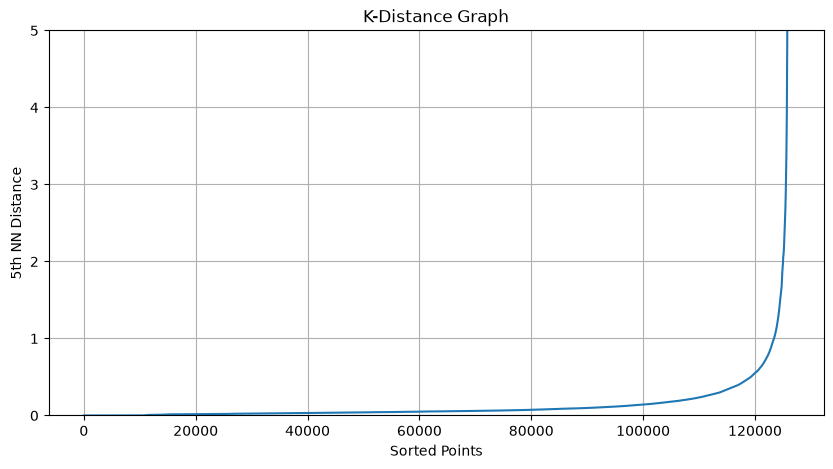

In [30]:
plt.figure(figsize=(10,5))
plt.plot(distances)
plt.ylim(0, 5)          # try 5, 10, 15, or 20
plt.title("K-Distance Graph")
plt.xlabel("Sorted Points")
plt.ylabel("5th NN Distance")
plt.grid(True)
plt.show()

In [31]:
X_scaled.describe().loc[["mean", "std"]]

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
mean,2.425388e-17,-8.803594e-16,2.062144e-16,1.516149e-16,5.640437e-19,4.512349e-19,-1.579322e-18,-1.128087e-18,-2.481792e-18,-1.895187e-17,...,1.579322e-17,-5.730684e-17,1.053634e-16,-2.295658e-17,3.181206e-17,3.158645e-17,1.737255e-17,-2.594601e-17,4.873337e-17,7.648432e-17
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,...,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00


In [32]:
X_scaled.shape

(125973, 41)

In [33]:
distances.max()

np.float64(392.9572640273378)

# Step 8: Train the DBSCAN Model

In [34]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.0, min_samples=5)

clusters = dbscan.fit_predict(X_scaled)

In [35]:
df['clusters'] = clusters

In [36]:
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty,clusters
0,0,0.815167,0.054456,0.594929,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,0
1,0,0.119018,0.034603,0.594929,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,1
2,0,0.815167,0.173474,0.276655,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,2
3,0,0.815167,0.320211,0.594929,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,3
4,0,0.815167,0.320211,0.594929,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,0.815167,0.173474,0.276655,0,0,0,0,0,0,...,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20,2
125969,8,0.119018,0.173474,0.594929,105,145,0,0,0,0,...,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21,10
125970,0,0.815167,0.058052,0.594929,2231,384,0,0,0,0,...,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18,5
125971,0,0.815167,0.003437,0.276655,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20,2


In [37]:
df[["attack", "clusters"]].head()

,attack,clusters
0,normal,0
1,normal,1
2,neptune,2
3,normal,3
4,normal,3


In [38]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

print("Number of Clusters :", n_clusters)

Number of Clusters : 211


In [39]:
noise = list(clusters).count(-1)

print("Number of Noise Points :", noise)

Number of Noise Points : 1990


In [40]:
df["clusters"].value_counts().sort_index()

clusters
-1       1990
 0       2016
 1       1213
 2      33132
 3      34644
        ...  
 206        5
 207        5
 208        5
 209        6
 210        4
Name: count, Length: 212, dtype: int64

## DBSCAN Model Training

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups data points based on density rather than predefined cluster counts.

The algorithm requires two parameters:

- **eps (ε):** Maximum distance between neighboring points.
- **min_samples:** Minimum number of neighboring points required to form a dense region.

Using the `eps` value estimated from the K-Distance Graph, the DBSCAN model is trained on the scaled dataset.

After training:

- Each observation receives a cluster label.
- Cluster labels (`0, 1, 2, ...`) represent discovered clusters.
- Label `-1` represents **noise points (anomalies)** that do not belong to any cluster.

The number of clusters and noise points are then analyzed to evaluate the clustering results.

In [41]:
print(df["clusters"].value_counts().head(20))

clusters
 3     34644
 2     33132
 10    13883
 5     10972
 4      6696
 8      3430
 9      2207
 0      2016
-1      1990
 18     1735
 13     1257
 1      1213
 7      1171
 38     1080
 14     1059
 32      560
 40      500
 43      485
 11      419
 21      310
Name: count, dtype: int64


In [42]:
print((clusters == -1).sum())

1990


In [43]:
df["clusters"].value_counts().sort_index()

clusters
-1       1990
 0       2016
 1       1213
 2      33132
 3      34644
        ...  
 206        5
 207        5
 208        5
 209        6
 210        4
Name: count, Length: 212, dtype: int64

## View all noisy points

In [44]:
noise_df = df[df["clusters"] == -1]

noise_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty,clusters
25,507,0.815167,0.018679,0.594929,437,14421,0,0,0,0,...,0.05,0.00,0.00,0.53,0.0,0.02,0.16,normal,20,-1
190,15159,0.815167,0.013924,0.594929,350,1185,0,0,0,6,...,0.02,0.00,0.00,0.00,0.0,0.00,0.00,warezclient,2,-1
405,7805,0.815167,0.018679,0.594929,1828,148722,0,0,0,1,...,0.08,0.02,0.00,0.00,0.0,0.00,0.00,normal,20,-1
511,4,0.815167,0.058052,0.594929,1308,328,0,0,0,0,...,0.00,0.50,0.14,0.00,0.0,0.00,0.00,normal,21,-1
535,0,0.815167,0.058052,0.012399,13794,2966,0,0,0,0,...,0.42,0.01,0.02,0.00,0.0,0.41,0.04,normal,17,-1


In [46]:
noise_df.shape

(1990, 44)

## What attacks are present in the noise?

In [45]:
noise_df["attack"].value_counts()

attack
normal             1515
portsweep           108
satan                82
ipsweep              53
neptune              45
back                 35
pod                  26
warezclient          24
buffer_overflow      19
nmap                 16
land                 10
imap                  9
teardrop              8
loadmodule            7
smurf                 6
multihop              5
guess_passwd          5
ftp_write             4
phf                   4
rootkit               3
perl                  3
warezmaster           2
spy                   1
Name: count, dtype: int64

# Results and Conclusion

DBSCAN was successfully applied to the NSL-KDD dataset for unsupervised network intrusion detection.

The optimal value of `eps` was selected by comparing clustering performance across multiple experiments.

| eps | Total Noise Points | Normal Connections in Noise |
|------|-------------------:|----------------------------:|
| 0.8 | 2766 | 2140 |
| 0.9 | 2326 | 1799 |
| 1.0 | 1990 | 1515 |

The results show that increasing the `eps` value reduced the number of normal network connections incorrectly classified as anomalies. Among the evaluated values, **eps = 1.0** achieved the best balance by reducing false positives while still detecting anomalous network traffic.

This project demonstrates how DBSCAN can be effectively used for anomaly detection without requiring labeled training data. It also highlights the importance of preprocessing, feature engineering, and hyperparameter tuning when applying density-based clustering to real-world cybersecurity datasets.